<a href="https://colab.research.google.com/github/iu5git/Deep-learning/blob/main/notebooks/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа Авторегрессия и LSTM

# Задание



Необходимо сгенерировать синтетические данные и обучить на них модель авторегрессии, модель LSTM.

Обучить рекуррентную нейронную сеть на реальных данных погоды по варианту.

Отчет должен содержать: титульный лист, задание с вариантом, скриншоты и краткие пояснения по каждому этапу лабораторной работы. Результаты моделей авторегрессии, LSTM на систетических данных, а также результаты обучения на реальных данных, итоговую таблицу со результатами для всех вариантов обучения

Вариант города соответствует группе: 1 - Москва, 2 - Санкт-Петербург, 3 - Новосибирск, 4 - Екатеринбург

# Задания для самостоятельной работы
1. Проведите обучение трех моделей по вашему варианту для вашего города.
2. Измените гиперпараметры обучения для улучшения модели: количество эпох, размер батча, скорость обучения
3. Создайте два варианта синтетических данных: первый вариант только сезонная компонента и шум; второй вариант только меняющийся тренд и шум
4. Измените конфигурацию нейросети: оставьте одну однонаправленную ячейку LSTM с выходным полносвязным слоем. Обучите ее на новых синтетических данных и сравните 3 разных варианта размерности состояния ячейки.
5. Укажите, какие действия помогли улучшить метрики ваших моделей и объясните почему.
6. Укажите в отчете как меняется количество обучаемых в LSTM параметров при изменении ее конфигурации

# Контрольные вопросы
1. Что такое временной ряд
2. Формула авторегрессии
3. Что такое рекуррентная нейронная сеть?
4. Отличия LSTM и GRU
5. Что такое вентиль? Какие вентили есть в LSTM?
6. Размерность входных, выходных данных и состояния для LSTM
7. Что такое двунаправленная LSTM?
8. Модель seq2seq
9. Генерация текста с помощью RNN

# Импорт библиотек

In [1]:
#!pip install torchsummary
import time
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader
from torchsummary import summary
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Часть 1 (Синтетические данные)

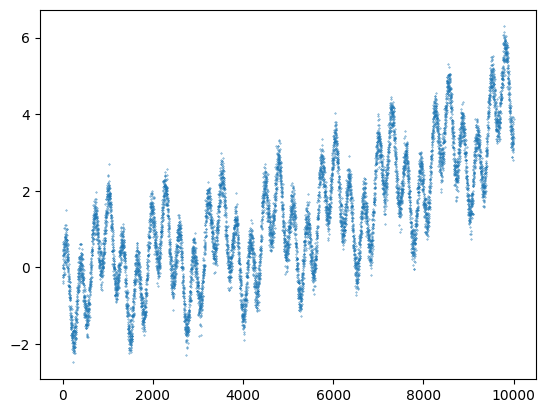

In [3]:
X = np.arange(10000)
y = np.sin(X/50)-np.sin(X/200)+(2*X/X.size)**2
y += np.random.normal(scale=0.25, size=y.size)
plt.scatter(X, y[:10000], s=0.1)

df = pd.Series(y)
#df = df.diff().dropna()

In [4]:
def getWindows(x):
    X.append(x.values.copy())
    return 0

WINDOW_SIZE = 200
X = []
df.rolling(WINDOW_SIZE+1).apply(getWindows, raw=False)
X = np.array(X)
y = X[:, WINDOW_SIZE:].copy()
X = X[:, :WINDOW_SIZE].copy()
X.shape, y.shape

((9800, 200), (9800, 1))

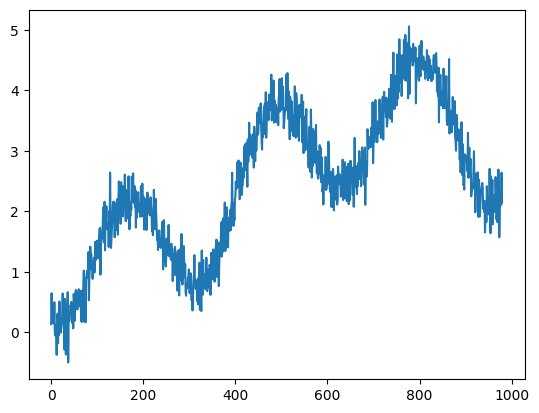

In [5]:
X_train = X[:X.shape[0]*9//10].copy()
y_train = y[:y.shape[0]*9//10].copy()
y_train -= X_train[:, -1:]
X_train = np.diff(X_train)

X_test = X[X.shape[0]*9//10:].copy()
y_test = y[y.shape[0]*9//10:].copy()
y_test -= X_test[:, -1:]
X_test = np.diff(X_test)

plt.plot(np.cumsum(y_test))

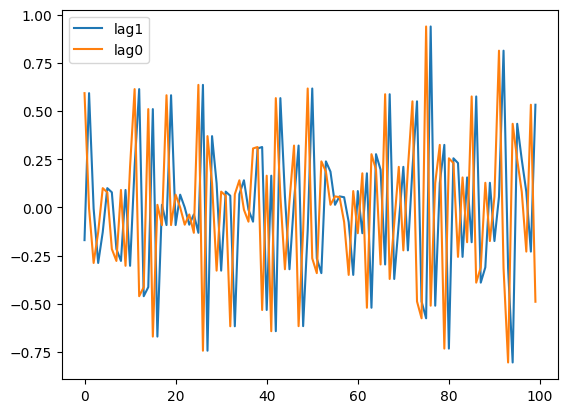

In [6]:
plt.plot(X_test[-100:,-1], label='lag1')
plt.plot(y_test[-100:], label='lag0')
plt.legend()

### Модель авторегрессии (AR)

In [7]:
def time_series_score(y_true, y_pred, X_true, previous_cnt=1):
    true_values = y_true#X_true[:, -1] + y_true
    pred_values = y_pred#X_true[:, -1] + y_pred

    last_value = X_true[:,-previous_cnt:].mean(axis=-1)
    variance_dummy = ((last_value - true_values)**2).mean()
    variance_pred = ((pred_values - true_values)**2).mean()
    #print(variance_dummy, variance_pred)
    r2 = 1 - variance_pred/variance_dummy
    #r2_adj = 1 - (1-r2)*(y_true.size - 1)/(y_true.size - X_true.shape[1] - 1)
    return r2

def recursive_predict(model, X):
    preds = []
    length = X.shape[0]
    last_vals = X[0].copy()
    for i in range(length):
        preds.append(model.predict([last_vals]))
        #tmp = last_vals[-1].copy()
        last_vals[:-1] = last_vals[1:]
        last_vals[-1:] = preds[-1] # + tmp
    return np.array(preds).reshape(-1)

  0%|          | 0/40 [00:00<?, ?it/s]

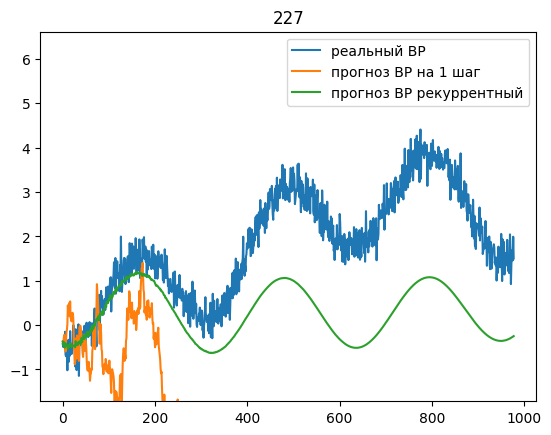

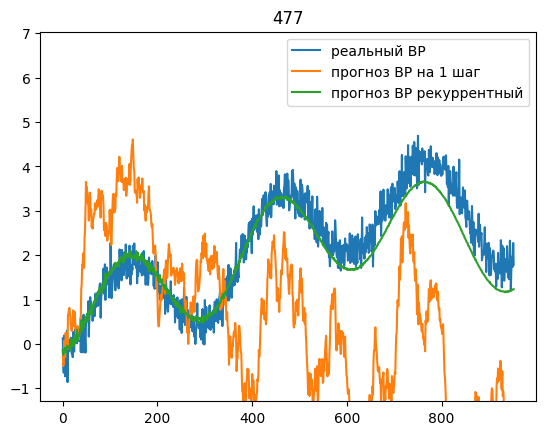

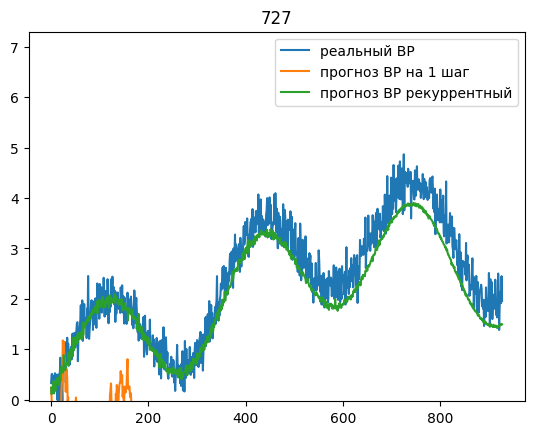

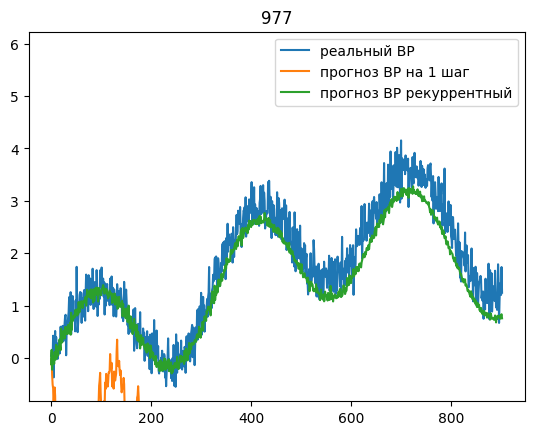

In [8]:
stats = []
series = []

windows = np.arange(2, 1001, 25)
for w in tqdm(windows):
    WINDOW_SIZE = w
    X = []
    df.rolling(WINDOW_SIZE+1).apply(getWindows, raw=False)
    X = np.array(X)
    y = X[:, WINDOW_SIZE:].copy()
    X = X[:, :WINDOW_SIZE].copy()

    X_train = X[:X.shape[0]*9//10].copy()
    y_train = y[:y.shape[0]*9//10].copy()
    y_train -= X_train[:, -1:]
    X_train = np.diff(X_train)

    X_test = X[X.shape[0]*9//10:].copy()
    y_test = y[y.shape[0]*9//10:].copy()
    y_test -= X_test[:, -1:]
    X_test = np.diff(X_test)

    lr = LinearRegression().fit(X_train, y_train)

    #preds = lr.predict(X_test)
    #preds = recursive_predict(lr, X_test)
    tmp = []
    p = [lr.predict(X_test), recursive_predict(lr, X_test)]
    for preds in p:
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        tss = time_series_score(y_test, preds, X_test)
        tmp.extend([mae, r2*100, tss*100])
    stats.append(tmp)
    series.append(p)
    if (len(stats)%10)==0:
        plt.plot(np.cumsum(y_test), label='реальный ВР')
        plt.plot(np.cumsum(p[0]), label='прогноз ВР на 1 шаг')
        plt.plot(np.cumsum(p[1]), label='прогноз ВР рекуррентный')
        plt.title(str(WINDOW_SIZE))
        plt.ylim(np.cumsum(y_test).min()*1.5, np.cumsum(y_test).max()*1.5)
        plt.legend(loc=0)
        plt.show()

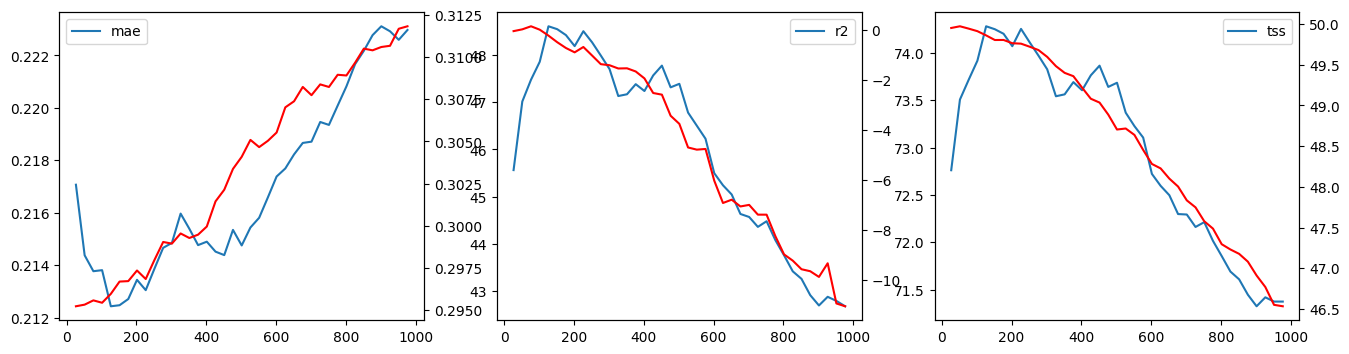

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(windows[1:], np.array(stats)[1:,0], label='mae')
ax[1].plot(windows[1:], np.array(stats)[1:,1], label='r2')
ax[2].plot(windows[1:], np.array(stats)[1:,2], label='tss')

ax[0].twinx().plot(windows[1:], np.array(stats)[1:,3], c='r', label='mae rec')
ax[1].twinx().plot(windows[1:], np.array(stats)[1:,4], c='r', label='r2 rec')
ax[2].twinx().plot(windows[1:], np.array(stats)[1:,5], c='r', label='tss rec')

for ax_ in ax:
    ax_.legend()

AR RMSE: 0.263	Naive RMSE: 0.368


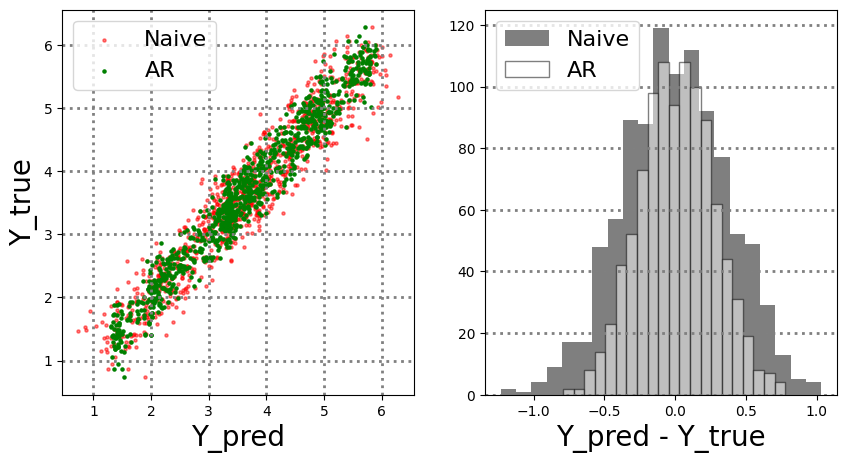

In [10]:
idx = np.array(stats)[:, 0].argmin()
WINDOW_SIZE = windows[idx]
X = []
df.rolling(WINDOW_SIZE+1).apply(getWindows, raw=False)
X = np.array(X)
y = X[:, WINDOW_SIZE:].copy()
X = X[:, :WINDOW_SIZE].copy()

X_train = X[:X.shape[0]*9//10].copy()
y_train = y[:y.shape[0]*9//10].copy()
y_train -= X_train[:, -1:]
X_train = np.diff(X_train)

X_test = X[X.shape[0]*9//10:].copy()
y_test = y[y.shape[0]*9//10:].copy()
y_test -= X_test[:, -1:]
X_test = np.diff(X_test)

preds_ar = X[X.shape[0]*9//10:, -1] + series[idx][0].flatten()
preds_naive = X[X.shape[0]*9//10:, -1:].mean(axis=1)
y_true = y[y.shape[0]*9//10:].flatten()
err_ar = y_true - preds_ar
err_naive = y_true - preds_naive

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(
    preds_naive,
    y_true,
    s=5,
    facecolor='red',
    alpha=0.5,
    label='Naive'
)
ax[0].scatter(
    preds_ar,
    y_true,
    s=5,
    facecolor='green',
    alpha=1,
    label='AR'
)
ax[1].hist(err_naive,
         bins=21,
         facecolor='k',
         alpha=0.5,
         label='Naive')
ax[1].hist(err_ar,
         bins=21,
         edgecolor='k',
         facecolor='w',
         alpha=0.5,
         label='AR')

ax[0].set_xlabel('Y_pred', fontsize=20)
ax[0].set_ylabel('Y_true', fontsize=20)
ax[1].set_xlabel('Y_pred - Y_true', fontsize=20)
ax[0].legend(fontsize=16)
ax[1].legend(fontsize=16)
ax[0].grid(axis='both', linestyle=':', linewidth=2, color='gray')
ax[1].grid(axis='y', linestyle=':', linewidth=2, color='gray')

print('AR RMSE: %.3f\tNaive RMSE: %.3f'%(err_ar.std(), err_naive.std()))

### LSTM

In [11]:
WINDOW_SIZE = 750
X = []
df.rolling(WINDOW_SIZE+1).apply(getWindows, raw=False)
X = np.array(X)
y = X[:, WINDOW_SIZE:].copy()
X = X[:, :WINDOW_SIZE].copy()
X_train = X[:X.shape[0]*9//10].copy()
y_train = y[:y.shape[0]*9//10].copy()
y_train -= X_train[:, -1:]
X_train = np.diff(X_train)

X_test = X[X.shape[0]*9//10:].copy()
y_test = y[y.shape[0]*9//10:].copy()
y_test -= X_test[:, -1:]
X_test = np.diff(X_test)

In [12]:
#MAX_VAL = np.abs(y_train).max()
tensor_X_train = torch.autograd.Variable(torch.Tensor(X_train))
tensor_y_train = torch.autograd.Variable(torch.Tensor(y_train))

tensor_X_test = torch.autograd.Variable(torch.Tensor(X_test))
tensor_y_test = torch.autograd.Variable(torch.Tensor(y_test))

dataset = TensorDataset(tensor_X_train, tensor_y_train)

dataset_test = TensorDataset(tensor_X_test, tensor_y_test)

dataloader = {}
dataloader['train'] = DataLoader(dataset, batch_size=512, shuffle=False)
dataloader['test'] = DataLoader(dataset_test, batch_size=128, shuffle=False)
del dataset, dataset_test

In [13]:
class LSTM(nn.Module):

    def __init__(self, num_features, input_size, hidden_size, num_layers,
                 bidirectional=True, p=0.4):
        super(LSTM, self).__init__()

        self.num_features = num_features
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            bidirectional=bidirectional,
                            num_layers=num_layers,
                            batch_first=True)
        self.dropout = nn.Dropout(p)

        self.fc = nn.Linear(2*hidden_size if bidirectional else hidden_size, num_features)


    def init_hidden(self, dim, device):
        h_0 = torch.autograd.Variable(
            torch.zeros(
                2*self.num_layers if self.bidirectional else self.num_layers,
                dim,
                self.hidden_size,
                device=device
            )
        )

        c_0 = torch.autograd.Variable(
            torch.zeros(
                2*self.num_layers if self.bidirectional else self.num_layers,
                dim,
                self.hidden_size,
                device=device
            )
        )
        return (h_0, c_0)


    def forward(self, x, hidden=None):
        if hidden is None:
            hidden = self.init_hidden(x.size(0), x.device)

        # Propagate input through LSTM
        lstm_out, hidden = self.lstm(x.view(x.size(0), x.size(1), 1), hidden)
        lstm_out = lstm_out[:, -1, :]
        #print(lstm_out.shape, [h.shape for h in hidden])
        h_out = lstm_out.view(x.size(0), -1)

        out = self.fc(self.dropout(h_out))

        return out, hidden

In [14]:
learning_rate = 0.01

num_features = 1
input_size = 1
hidden_size = 16
num_layers = 2
bidirectional = True
dropout_rate = 0.2

model = LSTM(
    num_features,
    input_size,
    hidden_size,
    num_layers,
    bidirectional,
    dropout_rate
).to(device)

criterion = torch.nn.MSELoss()    # среднекврадратическое отклонение
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# добавляем постепенное уменьшение шага обучения каждые 15 эпох
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

In [15]:
for name, weight in model.named_parameters():
    print(name, weight.shape)

lstm.weight_ih_l0 torch.Size([64, 1])
lstm.weight_hh_l0 torch.Size([64, 16])
lstm.bias_ih_l0 torch.Size([64])
lstm.bias_hh_l0 torch.Size([64])
lstm.weight_ih_l0_reverse torch.Size([64, 1])
lstm.weight_hh_l0_reverse torch.Size([64, 16])
lstm.bias_ih_l0_reverse torch.Size([64])
lstm.bias_hh_l0_reverse torch.Size([64])
lstm.weight_ih_l1 torch.Size([64, 32])
lstm.weight_hh_l1 torch.Size([64, 16])
lstm.bias_ih_l1 torch.Size([64])
lstm.bias_hh_l1 torch.Size([64])
lstm.weight_ih_l1_reverse torch.Size([64, 32])
lstm.weight_hh_l1_reverse torch.Size([64, 16])
lstm.bias_ih_l1_reverse torch.Size([64])
lstm.bias_hh_l1_reverse torch.Size([64])
fc.weight torch.Size([1, 32])
fc.bias torch.Size([1])


Эпоха: 40
Лучшее значение функции потерь: 0.07485699281096458
Текущее значение функции потерь: 0.07519648037850857


  0%|          | 0/680 [00:00<?, ?it/s]

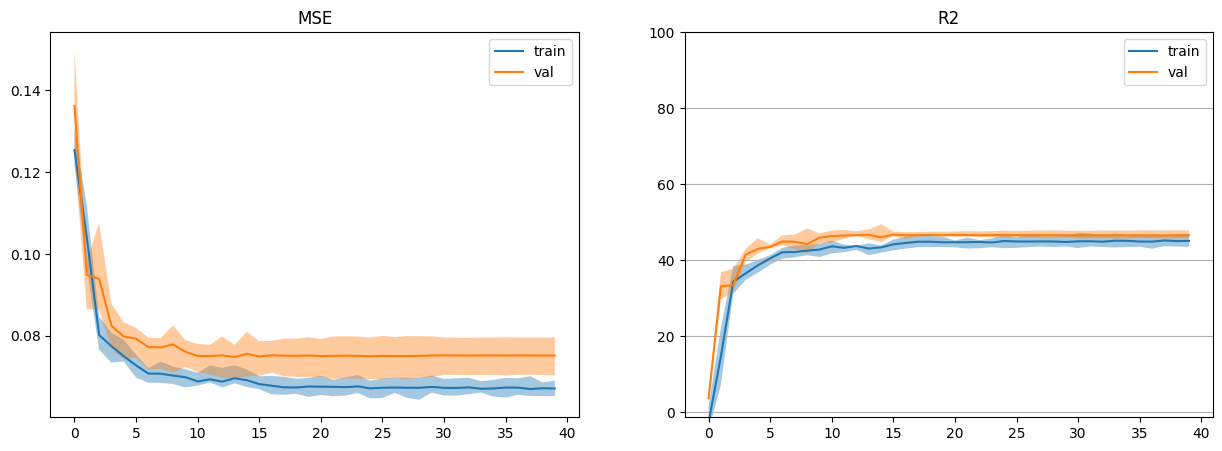

Обучение закончено за 35.008806228637695 секунд


In [16]:
EPOCHS = 40
REDRAW_EVERY = 1
steps_per_epoch = len(dataloader['train'])
steps_per_epoch_val = len(dataloader['test'])
# NEW
pbar = tqdm(total=EPOCHS*steps_per_epoch)
losses = []
losses_val = []
passed = 0
# для создания чекпоинта
best_loss = np.inf
checkpoint_path = 'ts.pth'
for epoch in range(EPOCHS):  # проход по набору данных несколько раз
    tmp = []
    model.train()
    hidden = None
    for i, batch in enumerate(dataloader['train'], 0):
        # получение одного минибатча; batch это двуэлементный список из [inputs, labels]
        inputs, labels = [xx.to(device) for xx in batch]

        # очищение прошлых градиентов с прошлой итерации
        optimizer.zero_grad()

        # прямой + обратный проходы + оптимизация
        if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
            print(inputs.shape[0], hidden[0].shape[1])
            hidden = None
        outputs, hidden = model(inputs, hidden)
        hidden = tuple([e.data for e in hidden])
        loss = criterion(outputs, labels)
        #loss = F.cross_entropy(outputs, labels)
        loss.backward()
        # обрезка градиентов
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # обновление параметров модели
        optimizer.step()

        # для подсчёта статистик
        accuracy = 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())
        tmp.append((loss.item(), accuracy))
        pbar.update(1)
    losses.append((np.mean(tmp, axis=0),
                   np.percentile(tmp, 25, axis=0),
                   np.percentile(tmp, 75, axis=0)))
    scheduler.step() # обновляем learning_rate каждую эпоху
    tmp = []
    model.eval()
    hidden = None
    with torch.no_grad(): # отключение автоматического дифференцирования
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data
            # на GPU
            inputs, labels = inputs.to(device), labels.to(device)
            if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
                print(inputs.shape[0], hidden[0].shape[1])
                hidden = None
            outputs, hidden = model(inputs, hidden)
            hidden = tuple([e.data for e in hidden])
            loss = criterion(outputs, labels)
            accuracy = 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())
            tmp.append((loss.item(), accuracy))
    losses_val.append((np.mean(tmp, axis=0),
                       np.percentile(tmp, 25, axis=0),
                       np.percentile(tmp, 75, axis=0)))
    # сохранение чекпоинта
    loss = losses_val[-1][0][0]
    if loss < best_loss:
        best_loss = loss
        torch.save(model.state_dict(), checkpoint_path)
    # обновление графиков
    if (epoch+1) % REDRAW_EVERY != 0:
        continue
    clear_output(wait=False)
    print('Эпоха: %s\n'
          'Лучшее значение функции потерь: %s\n'
          'Текущее значение функции потерь: %s' % (epoch+1, best_loss, loss))
    passed += pbar.format_dict['elapsed']
    pbar = tqdm(total=EPOCHS*steps_per_epoch, miniters=5)
    pbar.update((epoch+1)*steps_per_epoch)
    x_vals = np.arange(epoch+1)
    _, ax = plt.subplots(1, 2, figsize=(15, 5))
    stats = np.array(losses)
    stats_val = np.array(losses_val)
    ax[1].set_ylim(stats_val[:, 0, 1].min()-5, 100)
    ax[1].grid(axis='y')
    for i, title in enumerate(['MSE', 'R2']):
        ax[i].plot(x_vals, stats[:, 0, i], label='train')
        ax[i].fill_between(x_vals, stats[:, 1, i],
                           stats[:, 2, i], alpha=0.4)
        ax[i].plot(x_vals, stats_val[:, 0, i], label='val')
        ax[i].fill_between(x_vals,
                           stats_val[:, 1, i],
                           stats_val[:, 2, i], alpha=0.4)
        ax[i].legend()
        ax[i].set_title(title)
    plt.show()
model.load_state_dict(torch.load(checkpoint_path))
print('Обучение закончено за %s секунд' % passed)

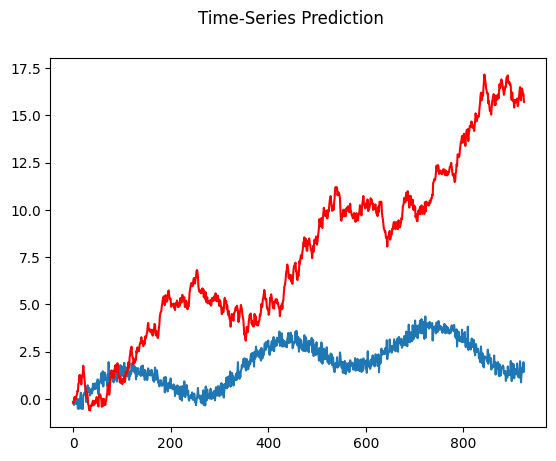

In [17]:
model.eval()
train_predict, _ = model(tensor_X_test.to(device))

data_predict = train_predict.data.cpu().numpy()#*MAX_VAL
dataY_plot = tensor_y_test.data.cpu().numpy()#*MAX_VAL

plt.plot(np.cumsum(dataY_plot))
plt.plot(np.cumsum(data_predict), color='r')
plt.suptitle('Time-Series Prediction')
plt.show()

LSTM RMSE: 0.268	Naive RMSE: 0.368


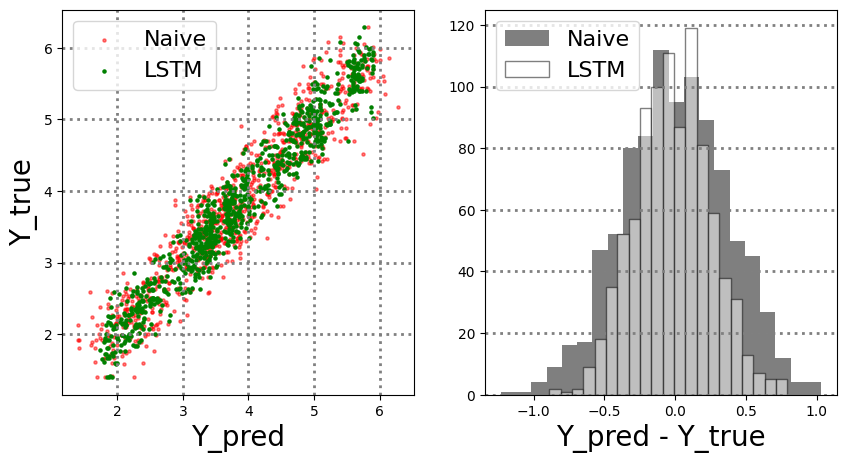

In [18]:
preds_ar = X[X.shape[0]*9//10:, -1] + data_predict.flatten()
preds_naive = X[X.shape[0]*9//10:, -1:].mean(axis=1)
y_true = y[y.shape[0]*9//10:].flatten()
err_ar = y_true - preds_ar
err_naive = y_true - preds_naive

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(
    preds_naive,
    y_true,
    s=5,
    facecolor='red',
    alpha=0.5,
    label='Naive'
)
ax[0].scatter(
    preds_ar,
    y_true,
    s=5,
    facecolor='green',
    alpha=1,
    label='LSTM'
)
ax[1].hist(err_naive,
         bins=21,
         facecolor='k',
         alpha=0.5,
         label='Naive')
ax[1].hist(err_ar,
         bins=21,
         edgecolor='k',
         facecolor='w',
         alpha=0.5,
         label='LSTM')

ax[0].set_xlabel('Y_pred', fontsize=20)
ax[0].set_ylabel('Y_true', fontsize=20)
ax[1].set_xlabel('Y_pred - Y_true', fontsize=20)
ax[0].legend(fontsize=16)
ax[1].legend(fontsize=16)
ax[0].grid(axis='both', linestyle=':', linewidth=2, color='gray')
ax[1].grid(axis='y', linestyle=':', linewidth=2, color='gray')

print('LSTM RMSE: %.3f\tNaive RMSE: %.3f'%(err_ar.std(), err_naive.std()))

  0%|          | 0/925 [00:00<?, ?it/s]

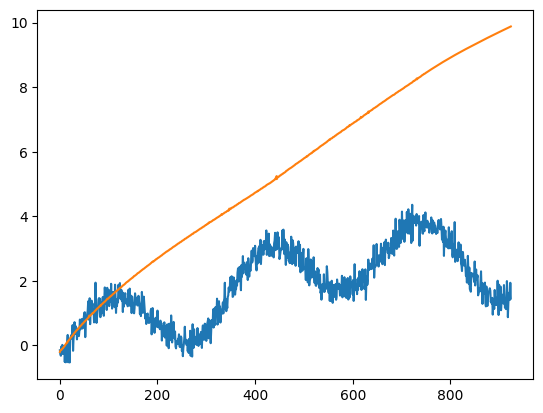

In [19]:
# Рекуррентный прогноз
model.eval()
last_value = tensor_X_test[0].clone()
preds = []
hidden = None
with torch.no_grad():
    for i in tqdm(range(y_test.shape[0])):
        output, hidden = model(last_value.view(1, last_value.size(-1)).to(device), hidden)
        hidden = tuple([e.data for e in hidden])
        preds.append(output.detach().cpu().item())
        last_value[:-1] = last_value[1:].clone()
        last_value[-1:] = preds[-1]
preds = np.array(preds)# * MAX_VAL
plt.plot(np.cumsum(y_test))
plt.plot(np.cumsum(preds))

In [20]:
print('='*50)
print('#', 'Тип', 'Кол-во точек', 'R2, %', 'TSS, %', sep='\t')
for p, label in zip([data_predict, preds], ['one-step', 'recursive']):
    for front in [2, 3, 5, 10, 50, -1]:
        print('#',
              label,
              front,
              '%.2f'%(r2_score(y_test[:front],
                               p[:front])*100),
              '%.2f'%(time_series_score(y_test[:front],
                                        p[:front],
                                        X_test[:front],
                                        previous_cnt=3)*100),
              sep='\t')
    print('='*50)

#	Тип	Кол-во точек	R2, %	TSS, %
#	one-step	2	-2329.16	87.89
#	one-step	3	-778.05	52.06
#	one-step	5	55.30	68.63
#	one-step	10	58.72	65.82
#	one-step	50	43.81	49.57
#	one-step	-1	46.67	51.45
#	recursive	2	-4722.63	68.76
#	recursive	3	-523.91	45.39
#	recursive	5	-6.21	8.31
#	recursive	10	2.08	7.03
#	recursive	50	-0.38	9.32
#	recursive	-1	-0.18	8.82


## Часть 2 (Реальные данные)

In [21]:
!gdown --folder https://drive.google.com/drive/folders/1FtEVU702DjlTjoecxbbNBl5nP9SCu7Rw

Retrieving folder contents
Processing file 1mBIyf4Zo4ChrQ0R6EvwdrkQzrAKpX27c climate_ekb.csv
Processing file 1B0RgTX4TN8WuLkXins8D1pnrdhntHPXQ climate_moscow.csv
Processing file 18AVqfU6mtCwuqkuC6feZs9slE-WJk9MU climate_novosib.csv
Processing file 12SudJ27Zzxrd2eg4wsMDrfDQMTkacuFL climate_piter.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1mBIyf4Zo4ChrQ0R6EvwdrkQzrAKpX27c
To: /content/climate/climate_ekb.csv
100% 3.75M/3.75M [00:00<00:00, 182MB/s]
Downloading...
From: https://drive.google.com/uc?id=1B0RgTX4TN8WuLkXins8D1pnrdhntHPXQ
To: /content/climate/climate_moscow.csv
100% 3.70M/3.70M [00:00<00:00, 276MB/s]
Downloading...
From: https://drive.google.com/uc?id=18AVqfU6mtCwuqkuC6feZs9slE-WJk9MU
To: /content/climate/climate_novosib.csv
100% 3.73M/3.73M [00:00<00:00, 249MB/s]
Downloading...
From: https://drive.google.com/uc?id=12SudJ27Zzxrd2eg4wsMDrfDQMTkacuFL
To: /content/

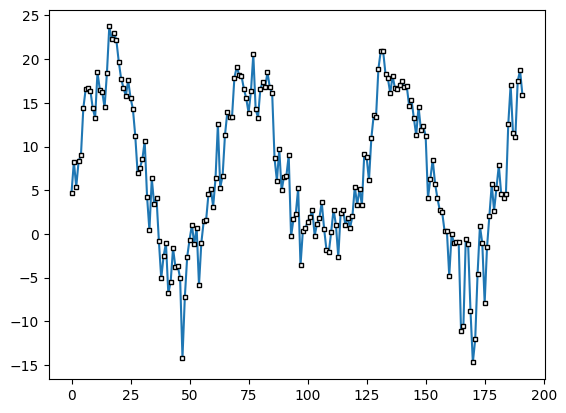

In [22]:
# По варианту проделать те же шаги для набора данных с погодой за полвека
df = pd.read_csv('climate/climate_piter.csv', sep='\t')
df = df[df.year>1972].copy()
df['quartile'] = df.day//7
plt.plot(
    df.groupby(['year', 'month', 'quartile'])
      .Temperature
      .aggregate('mean')
      .iloc[-4*12*4:]
      .reset_index()
      .Temperature,
   #rot=90,
   #ylabel='temperature',
   marker='s',
   markersize=3,
   markerfacecolor='white',
   markeredgecolor='k'
)
df = df.Temperature.diff().dropna()

**Naive**

In [23]:
# Шаг 1 — Подготовка данных
def getWindows(x):
    X.append(x.values.copy())
    return 0

WINDOW_SIZE = 200
X = []
df.rolling(WINDOW_SIZE+1).apply(getWindows, raw=False)
X = np.array(X)
y = X[:, WINDOW_SIZE:].copy()
X = X[:, :WINDOW_SIZE].copy()

X_train = X[:X.shape[0]*9//10].copy()
y_train = y[:y.shape[0]*9//10].copy()
y_train -= X_train[:, -1:]
X_train = np.diff(X_train)

X_test = X[X.shape[0]*9//10:].copy()
y_test = y[y.shape[0]*9//10:].copy()
y_test -= X_test[:, -1:]
X_test = np.diff(X_test)

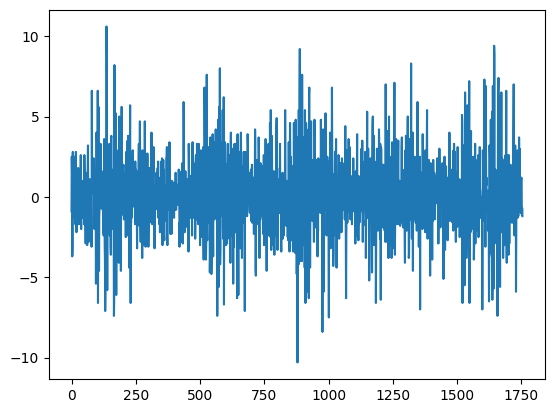

In [24]:
plt.plot(np.cumsum(y_test))

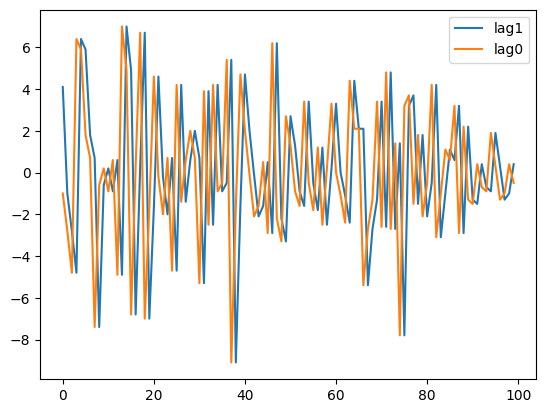

In [25]:
plt.plot(X_test[-100:,-1], label='lag1')
plt.plot(y_test[-100:], label='lag0')
plt.legend()

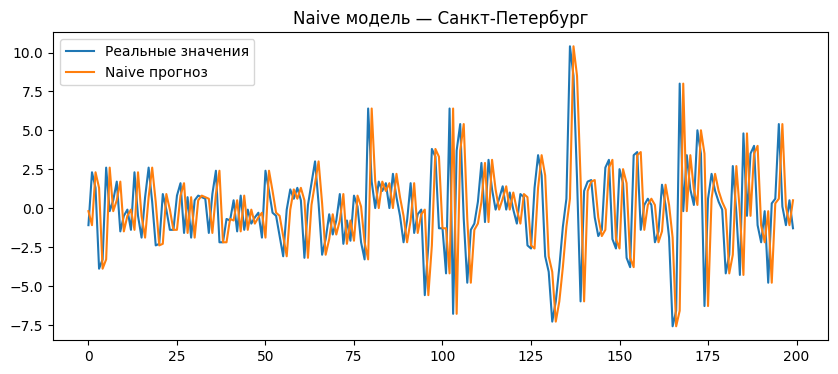

Naive RMSE: 3.247


In [26]:
preds_naive = X[X.shape[0]*9//10:, -1:].mean(axis=1)
y_true = y[y.shape[0]*9//10:].flatten()
err_naive = y_true - preds_naive

plt.figure(figsize=(10, 4))
plt.plot(y_true[:200], label='Реальные значения')
plt.plot(preds_naive[:200], label='Naive прогноз')
plt.legend()
plt.title('Naive модель — Санкт-Петербург')
plt.show()

print('Naive RMSE: %.3f' % err_naive.std())

**AR**

In [27]:
stats = []
series = []

windows = np.arange(2, 1001, 25)
for w in tqdm(windows):
    WINDOW_SIZE = w
    X = []
    df.rolling(WINDOW_SIZE+1).apply(getWindows, raw=False)
    X = np.array(X)
    y = X[:, WINDOW_SIZE:].copy()
    X = X[:, :WINDOW_SIZE].copy()

    X_train = X[:X.shape[0]*9//10].copy()
    y_train = y[:y.shape[0]*9//10].copy()
    y_train -= X_train[:, -1:]
    X_train = np.diff(X_train)

    X_test = X[X.shape[0]*9//10:].copy()
    y_test = y[y.shape[0]*9//10:].copy()
    y_test -= X_test[:, -1:]
    X_test = np.diff(X_test)

    lr = LinearRegression().fit(X_train, y_train)
    tmp = []
    p = [lr.predict(X_test), recursive_predict(lr, X_test)]
    for preds in p:
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        tss = time_series_score(y_test, preds, X_test)
        tmp.extend([mae, r2*100, tss*100])
    stats.append(tmp)
    series.append(p)

print('AR готов')

  0%|          | 0/40 [00:00<?, ?it/s]

AR готов


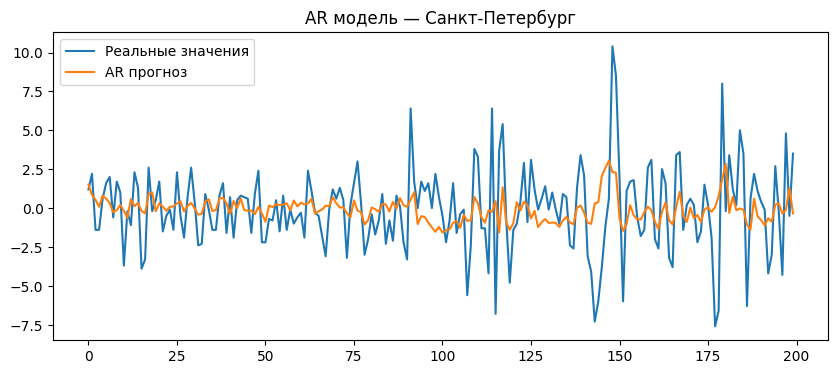

Лучший размер окна: 77
AR RMSE: 2.285	Naive RMSE: 3.242


In [28]:
idx = np.array(stats)[:, 0].argmin()
WINDOW_SIZE = windows[idx]
X = []
df.rolling(WINDOW_SIZE+1).apply(getWindows, raw=False)
X = np.array(X)
y = X[:, WINDOW_SIZE:].copy()
X = X[:, :WINDOW_SIZE].copy()

X_train = X[:X.shape[0]*9//10].copy()
y_train = y[:y.shape[0]*9//10].copy()
y_train -= X_train[:, -1:]
X_train = np.diff(X_train)

X_test = X[X.shape[0]*9//10:].copy()
y_test = y[y.shape[0]*9//10:].copy()
y_test -= X_test[:, -1:]
X_test = np.diff(X_test)

preds_ar = X[X.shape[0]*9//10:, -1] + series[idx][0].flatten()
preds_naive = X[X.shape[0]*9//10:, -1:].mean(axis=1)
y_true = y[y.shape[0]*9//10:].flatten()
err_ar = y_true - preds_ar
err_naive = y_true - preds_naive

plt.figure(figsize=(10, 4))
plt.plot(y_true[:200], label='Реальные значения')
plt.plot(preds_ar[:200], label='AR прогноз')
plt.legend()
plt.title('AR модель — Санкт-Петербург')
plt.show()

print('Лучший размер окна: %d' % WINDOW_SIZE)
print('AR RMSE: %.3f\tNaive RMSE: %.3f' % (err_ar.std(), err_naive.std()))

LSTM

In [29]:
WINDOW_SIZE = 750
X = []
df.rolling(WINDOW_SIZE+1).apply(getWindows, raw=False)
X = np.array(X)
y = X[:, WINDOW_SIZE:].copy()
X = X[:, :WINDOW_SIZE].copy()

X_train = X[:X.shape[0]*9//10].copy()
y_train = y[:y.shape[0]*9//10].copy()
y_train -= X_train[:, -1:]
X_train = np.diff(X_train)

X_test = X[X.shape[0]*9//10:].copy()
y_test = y[y.shape[0]*9//10:].copy()
y_test -= X_test[:, -1:]
X_test = np.diff(X_test)

tensor_X_train = torch.autograd.Variable(torch.Tensor(X_train))
tensor_y_train = torch.autograd.Variable(torch.Tensor(y_train))
tensor_X_test = torch.autograd.Variable(torch.Tensor(X_test))
tensor_y_test = torch.autograd.Variable(torch.Tensor(y_test))

dataset = TensorDataset(tensor_X_train, tensor_y_train)
dataset_test = TensorDataset(tensor_X_test, tensor_y_test)

dataloader = {}
dataloader['train'] = DataLoader(dataset, batch_size=512, shuffle=False)
dataloader['test'] = DataLoader(dataset_test, batch_size=128, shuffle=False)
del dataset, dataset_test

print('Данные готовы')

Данные готовы


In [30]:
print(device)

cuda


In [31]:
learning_rate = 0.01

num_features = 1
input_size = 1
hidden_size = 16
num_layers = 2
bidirectional = True
dropout_rate = 0.2

model = LSTM(
    num_features,
    input_size,
    hidden_size,
    num_layers,
    bidirectional,
    dropout_rate
).to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

EPOCHS = 40
REDRAW_EVERY = 1
steps_per_epoch = len(dataloader['train'])
pbar = tqdm(total=EPOCHS*steps_per_epoch)
losses = []
losses_val = []
passed = 0
best_loss = np.inf
checkpoint_path = 'ts_piter.pth'

for epoch in range(EPOCHS):
    tmp = []
    model.train()
    hidden = None
    for i, batch in enumerate(dataloader['train'], 0):
        inputs, labels = [xx.to(device) for xx in batch]
        optimizer.zero_grad()
        if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
            hidden = None
        outputs, hidden = model(inputs, hidden)
        hidden = tuple([e.data for e in hidden])
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        accuracy = 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())
        tmp.append((loss.item(), accuracy))
        pbar.update(1)
    losses.append((np.mean(tmp, axis=0),
                   np.percentile(tmp, 25, axis=0),
                   np.percentile(tmp, 75, axis=0)))
    scheduler.step()
    tmp = []
    model.eval()
    hidden = None
    with torch.no_grad():
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
                hidden = None
            outputs, hidden = model(inputs, hidden)
            hidden = tuple([e.data for e in hidden])
            loss = criterion(outputs, labels)
            accuracy = 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())
            tmp.append((loss.item(), accuracy))
    losses_val.append((np.mean(tmp, axis=0),
                       np.percentile(tmp, 25, axis=0),
                       np.percentile(tmp, 75, axis=0)))
    loss = losses_val[-1][0][0]
    if loss < best_loss:
        best_loss = loss
        torch.save(model.state_dict(), checkpoint_path)

print('Обучение завершено')

  0%|          | 0/1200 [00:00<?, ?it/s]

Обучение завершено


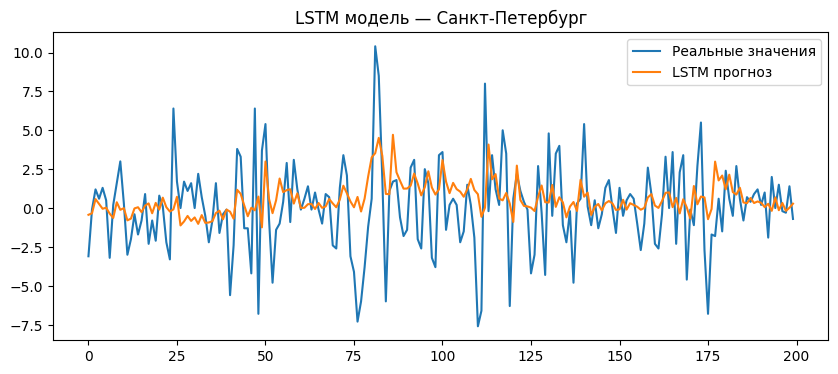

LSTM RMSE: 2.343	Naive RMSE: 3.275


In [32]:
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

train_predict, _ = model(tensor_X_test.to(device))
data_predict = train_predict.data.cpu().numpy()
dataY_plot = tensor_y_test.data.cpu().numpy()

preds_lstm = X[X.shape[0]*9//10:, -1] + data_predict.flatten()
preds_naive = X[X.shape[0]*9//10:, -1:].mean(axis=1)
y_true = y[y.shape[0]*9//10:].flatten()
err_lstm = y_true - preds_lstm
err_naive = y_true - preds_naive

plt.figure(figsize=(10, 4))
plt.plot(y_true[:200], label='Реальные значения')
plt.plot(preds_lstm[:200], label='LSTM прогноз')
plt.legend()
plt.title('LSTM модель — Санкт-Петербург')
plt.show()

print('LSTM RMSE: %.3f\tNaive RMSE: %.3f' % (err_lstm.std(), err_naive.std()))

**Задание 2. Измените гиперпараметры обучения для улучшения модели: количество эпох, размер батча, скорость обучения**

In [33]:
learning_rate = 0.001
batch_size_train = 256

tensor_X_train = torch.autograd.Variable(torch.Tensor(X_train))
tensor_y_train = torch.autograd.Variable(torch.Tensor(y_train))
tensor_X_test = torch.autograd.Variable(torch.Tensor(X_test))
tensor_y_test = torch.autograd.Variable(torch.Tensor(y_test))

dataset = TensorDataset(tensor_X_train, tensor_y_train)
dataset_test = TensorDataset(tensor_X_test, tensor_y_test)
dataloader = {}
dataloader['train'] = DataLoader(dataset, batch_size=batch_size_train, shuffle=False)
dataloader['test'] = DataLoader(dataset_test, batch_size=128, shuffle=False)
del dataset, dataset_test

model2 = LSTM(1, 1, 16, 2, True, 0.2).to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

EPOCHS = 60
pbar = tqdm(total=EPOCHS*len(dataloader['train']))
losses, losses_val = [], []
best_loss = np.inf
checkpoint_path2 = 'ts_piter2.pth'

for epoch in range(EPOCHS):
    tmp = []
    model2.train()
    hidden = None
    for i, batch in enumerate(dataloader['train'], 0):
        inputs, labels = [xx.to(device) for xx in batch]
        optimizer.zero_grad()
        if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
            hidden = None
        outputs, hidden = model2(inputs, hidden)
        hidden = tuple([e.data for e in hidden])
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
        optimizer.step()
        accuracy = 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())
        tmp.append((loss.item(), accuracy))
        pbar.update(1)
    losses.append((np.mean(tmp, axis=0),
                   np.percentile(tmp, 25, axis=0),
                   np.percentile(tmp, 75, axis=0)))
    scheduler.step()
    tmp = []
    model2.eval()
    hidden = None
    with torch.no_grad():
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
                hidden = None
            outputs, hidden = model2(inputs, hidden)
            hidden = tuple([e.data for e in hidden])
            loss = criterion(outputs, labels)
            accuracy = 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())
            tmp.append((loss.item(), accuracy))
    losses_val.append((np.mean(tmp, axis=0),
                       np.percentile(tmp, 25, axis=0),
                       np.percentile(tmp, 75, axis=0)))
    loss = losses_val[-1][0][0]
    if loss < best_loss:
        best_loss = loss
        torch.save(model2.state_dict(), checkpoint_path2)

print('Обучение завершено')

  0%|          | 0/3600 [00:00<?, ?it/s]

Обучение завершено


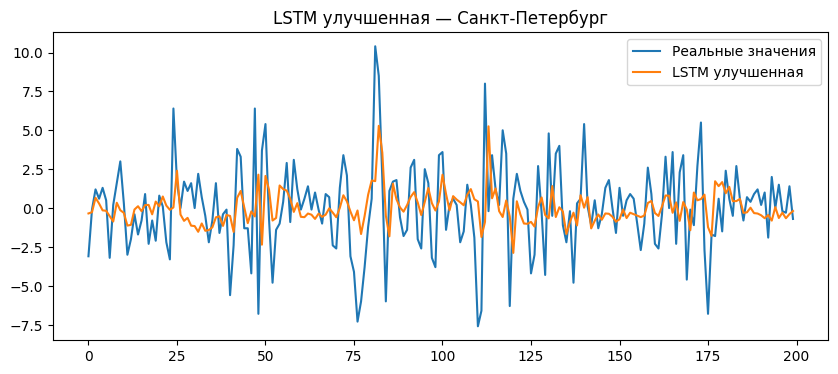

LSTM улучшенная RMSE: 2.358
LSTM базовая RMSE:    2.343
AR RMSE:              2.285
Naive RMSE:           3.275


In [34]:
model2.load_state_dict(torch.load(checkpoint_path2))
model2.eval()

train_predict2, _ = model2(tensor_X_test.to(device))
data_predict2 = train_predict2.data.cpu().numpy()

preds_lstm2 = X[X.shape[0]*9//10:, -1] + data_predict2.flatten()
y_true = y[y.shape[0]*9//10:].flatten()
err_lstm2 = y_true - preds_lstm2

plt.figure(figsize=(10, 4))
plt.plot(y_true[:200], label='Реальные значения')
plt.plot(preds_lstm2[:200], label='LSTM улучшенная')
plt.legend()
plt.title('LSTM улучшенная — Санкт-Петербург')
plt.show()

print('LSTM улучшенная RMSE: %.3f' % err_lstm2.std())
print('LSTM базовая RMSE:    2.343')
print('AR RMSE:              2.285')
print('Naive RMSE:           3.275')

Стало хуже. Увеличим hidden_size

In [35]:
learning_rate = 0.001

model3 = LSTM(1, 1, 32, 2, True, 0.2).to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

EPOCHS = 60
pbar = tqdm(total=EPOCHS*len(dataloader['train']))
losses, losses_val = [], []
best_loss = np.inf
checkpoint_path3 = 'ts_piter3.pth'

for epoch in range(EPOCHS):
    tmp = []
    model3.train()
    hidden = None
    for i, batch in enumerate(dataloader['train'], 0):
        inputs, labels = [xx.to(device) for xx in batch]
        optimizer.zero_grad()
        if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
            hidden = None
        outputs, hidden = model3(inputs, hidden)
        hidden = tuple([e.data for e in hidden])
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model3.parameters(), 1.0)
        optimizer.step()
        accuracy = 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())
        tmp.append((loss.item(), accuracy))
        pbar.update(1)
    losses.append((np.mean(tmp, axis=0),
                   np.percentile(tmp, 25, axis=0),
                   np.percentile(tmp, 75, axis=0)))
    scheduler.step()
    tmp = []
    model3.eval()
    hidden = None
    with torch.no_grad():
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
                hidden = None
            outputs, hidden = model3(inputs, hidden)
            hidden = tuple([e.data for e in hidden])
            loss = criterion(outputs, labels)
            accuracy = 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())
            tmp.append((loss.item(), accuracy))
    losses_val.append((np.mean(tmp, axis=0),
                       np.percentile(tmp, 25, axis=0),
                       np.percentile(tmp, 75, axis=0)))
    loss = losses_val[-1][0][0]
    if loss < best_loss:
        best_loss = loss
        torch.save(model3.state_dict(), checkpoint_path3)

print('Обучение завершено')

  0%|          | 0/3600 [00:00<?, ?it/s]

Обучение завершено


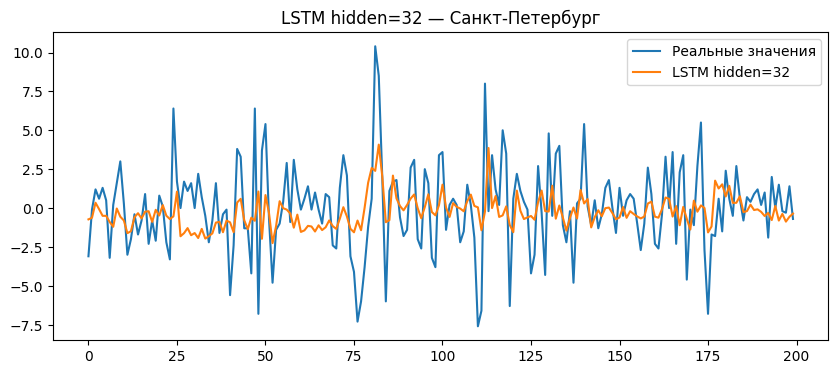

LSTM hidden=32 RMSE:  2.314
LSTM базовая RMSE:    2.343
AR RMSE:              2.285
Naive RMSE:           3.275


In [36]:
model3.load_state_dict(torch.load(checkpoint_path3))
model3.eval()

train_predict3, _ = model3(tensor_X_test.to(device))
data_predict3 = train_predict3.data.cpu().numpy()

preds_lstm3 = X[X.shape[0]*9//10:, -1] + data_predict3.flatten()
y_true = y[y.shape[0]*9//10:].flatten()
err_lstm3 = y_true - preds_lstm3

plt.figure(figsize=(10, 4))
plt.plot(y_true[:200], label='Реальные значения')
plt.plot(preds_lstm3[:200], label='LSTM hidden=32')
plt.legend()
plt.title('LSTM hidden=32 — Санкт-Петербург')
plt.show()

print('LSTM hidden=32 RMSE:  %.3f' % err_lstm3.std())
print('LSTM базовая RMSE:    2.343')
print('AR RMSE:              2.285')
print('Naive RMSE:           3.275')

Стало лучше. Проведём третий эксперимент

In [37]:
model4 = LSTM(1, 1, 64, 2, True, 0.2).to(device)
optimizer = torch.optim.Adam(model4.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

EPOCHS = 60
pbar = tqdm(total=EPOCHS*len(dataloader['train']))
losses, losses_val = [], []
best_loss = np.inf
checkpoint_path4 = 'ts_piter4.pth'

for epoch in range(EPOCHS):
    tmp = []
    model4.train()
    hidden = None
    for i, batch in enumerate(dataloader['train'], 0):
        inputs, labels = [xx.to(device) for xx in batch]
        optimizer.zero_grad()
        if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
            hidden = None
        outputs, hidden = model4(inputs, hidden)
        hidden = tuple([e.data for e in hidden])
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model4.parameters(), 1.0)
        optimizer.step()
        tmp.append((loss.item(), 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())))
        pbar.update(1)
    losses.append((np.mean(tmp, axis=0), np.percentile(tmp, 25, axis=0), np.percentile(tmp, 75, axis=0)))
    scheduler.step()
    tmp = []
    model4.eval()
    hidden = None
    with torch.no_grad():
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = [xx.to(device) for xx in data]
            if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
                hidden = None
            outputs, hidden = model4(inputs, hidden)
            hidden = tuple([e.data for e in hidden])
            loss = criterion(outputs, labels)
            tmp.append((loss.item(), 100*r2_score(labels.detach().cpu().numpy(), outputs.detach().cpu().numpy())))
    losses_val.append((np.mean(tmp, axis=0), np.percentile(tmp, 25, axis=0), np.percentile(tmp, 75, axis=0)))
    loss = losses_val[-1][0][0]
    if loss < best_loss:
        best_loss = loss
        torch.save(model4.state_dict(), checkpoint_path4)

print('Эксперимент 3 завершён')

  0%|          | 0/3600 [00:00<?, ?it/s]

Эксперимент 3 завершён


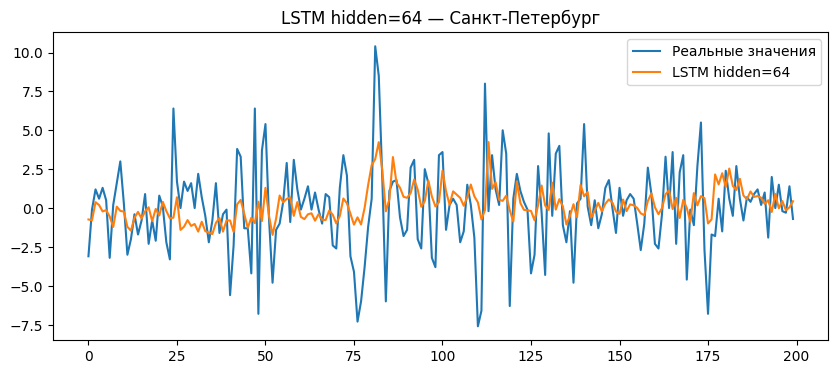

LSTM hidden=64 RMSE:  2.316
LSTM hidden=32 RMSE:  2.314
LSTM базовая RMSE:    2.343
AR RMSE:              2.285
Naive RMSE:           3.275


In [38]:
model4.load_state_dict(torch.load(checkpoint_path4))
model4.eval()

train_predict4, _ = model4(tensor_X_test.to(device))
data_predict4 = train_predict4.data.cpu().numpy()

preds_lstm4 = X[X.shape[0]*9//10:, -1] + data_predict4.flatten()
y_true = y[y.shape[0]*9//10:].flatten()
err_lstm4 = y_true - preds_lstm4

plt.figure(figsize=(10, 4))
plt.plot(y_true[:200], label='Реальные значения')
plt.plot(preds_lstm4[:200], label='LSTM hidden=64')
plt.legend()
plt.title('LSTM hidden=64 — Санкт-Петербург')
plt.show()

print('LSTM hidden=64 RMSE:  %.3f' % err_lstm4.std())
print('LSTM hidden=32 RMSE:  2.314')
print('LSTM базовая RMSE:    2.343')
print('AR RMSE:              2.285')
print('Naive RMSE:           3.275')

**Задание 3**

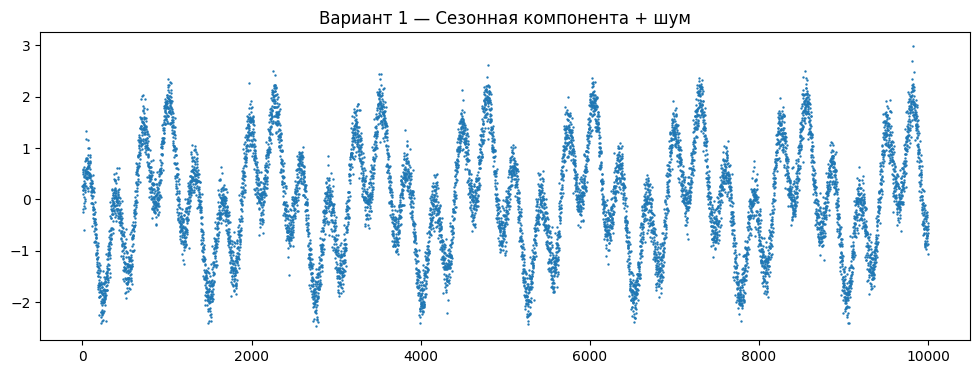

In [39]:
# Вариант 1 — только сезонная компонента + шум:
X_idx = np.arange(10000)
y_seasonal = np.sin(X_idx/50) - np.sin(X_idx/200)
y_seasonal += np.random.normal(scale=0.25, size=y_seasonal.size)

plt.figure(figsize=(12, 4))
plt.scatter(X_idx, y_seasonal, s=0.5)
plt.title('Вариант 1 — Сезонная компонента + шум')
plt.show()

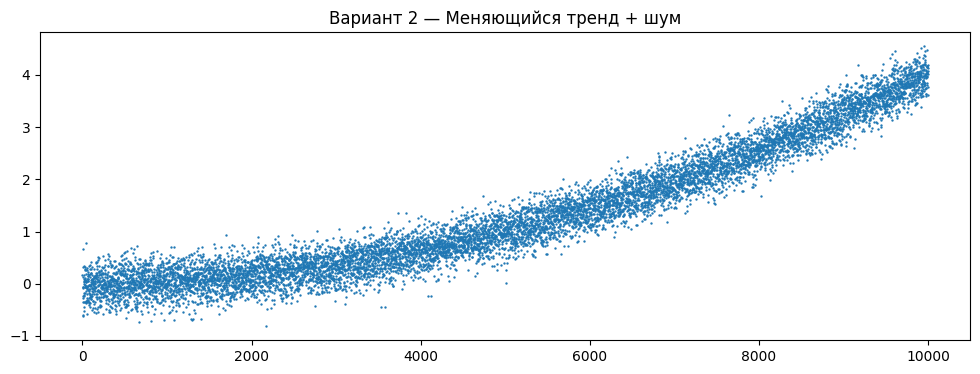

In [40]:
# Вариант 2 — меняющийся тренд + шум
y_trend = (2*X_idx/X_idx.size)**2
y_trend += np.random.normal(scale=0.25, size=y_trend.size)

plt.figure(figsize=(12, 4))
plt.scatter(X_idx, y_trend, s=0.5)
plt.title('Вариант 2 — Меняющийся тренд + шум')
plt.show()

**Задание 4**

упрощённая LSTM (1 слой, однонаправленная) на синтетических данных из задания 3, сравниваем hidden_size = 8, 16, 32.

In [41]:
WINDOW_SIZE_SYN = 200

def prepare_data(y_data):
    df_syn = pd.Series(y_data)
    X_syn = []
    def gw(x):
        X_syn.append(x.values.copy())
        return 0
    df_syn.rolling(WINDOW_SIZE_SYN+1).apply(gw, raw=False)
    X_syn = np.array(X_syn)
    y_syn = X_syn[:, WINDOW_SIZE_SYN:].copy()
    X_syn = X_syn[:, :WINDOW_SIZE_SYN].copy()

    X_tr = X_syn[:X_syn.shape[0]*9//10].copy()
    y_tr = y_syn[:y_syn.shape[0]*9//10].copy()
    y_tr -= X_tr[:, -1:]
    X_tr = np.diff(X_tr)

    X_te = X_syn[X_syn.shape[0]*9//10:].copy()
    y_te = y_syn[y_syn.shape[0]*9//10:].copy()
    y_te -= X_te[:, -1:]
    X_te = np.diff(X_te)

    t_Xtr = torch.Tensor(X_tr)
    t_ytr = torch.Tensor(y_tr)
    t_Xte = torch.Tensor(X_te)
    t_yte = torch.Tensor(y_te)

    dl = {}
    dl['train'] = DataLoader(TensorDataset(t_Xtr, t_ytr), batch_size=256, shuffle=False)
    dl['test'] = DataLoader(TensorDataset(t_Xte, t_yte), batch_size=128, shuffle=False)
    return dl, t_Xte, y_te

dl_seasonal, t_Xte_seasonal, y_te_seasonal = prepare_data(y_seasonal)
dl_trend, t_Xte_trend, y_te_trend = prepare_data(y_trend)

print('Данные готовы')

Данные готовы


обучит 6 моделей сразу (3 hidden_size × 2 датасета):

In [42]:
results_task4 = {}

for dataset_name, dl, t_Xte, y_te in [('seasonal', dl_seasonal, t_Xte_seasonal, y_te_seasonal),
                                        ('trend', dl_trend, t_Xte_trend, y_te_trend)]:
    results_task4[dataset_name] = {}
    for hidden_size in [8, 16, 32]:
        model_tmp = LSTM(1, 1, hidden_size, 1, False, 0.2).to(device)
        optimizer_tmp = torch.optim.Adam(model_tmp.parameters(), lr=0.001)
        scheduler_tmp = optim.lr_scheduler.StepLR(optimizer_tmp, step_size=15, gamma=0.1)
        criterion_tmp = torch.nn.MSELoss()

        best_loss = np.inf
        best_preds = None

        for epoch in range(30):
            model_tmp.train()
            hidden = None
            for batch in dl['train']:
                inputs, labels = [xx.to(device) for xx in batch]
                optimizer_tmp.zero_grad()
                if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
                    hidden = None
                outputs, hidden = model_tmp(inputs, hidden)
                hidden = tuple([e.data for e in hidden])
                loss = criterion_tmp(outputs, labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model_tmp.parameters(), 1.0)
                optimizer_tmp.step()
            scheduler_tmp.step()

            model_tmp.eval()
            hidden = None
            tmp_loss = []
            with torch.no_grad():
                for batch in dl['test']:
                    inputs, labels = [xx.to(device) for xx in batch]
                    if hidden is not None and inputs.shape[0] != hidden[0].shape[1]:
                        hidden = None
                    outputs, hidden = model_tmp(inputs, hidden)
                    hidden = tuple([e.data for e in hidden])
                    tmp_loss.append(criterion_tmp(outputs, labels).item())
            if np.mean(tmp_loss) < best_loss:
                best_loss = np.mean(tmp_loss)
                preds, _ = model_tmp(t_Xte.to(device))
                best_preds = preds.detach().cpu().numpy()

        err = y_te.flatten() - best_preds.flatten()
        rmse = err.std()
        results_task4[dataset_name][hidden_size] = rmse
        print(f'{dataset_name} | hidden={hidden_size} | RMSE: {rmse:.3f}')

print('Все модели обучены')

seasonal | hidden=8 | RMSE: 0.285
seasonal | hidden=16 | RMSE: 0.282
seasonal | hidden=32 | RMSE: 0.276
trend | hidden=8 | RMSE: 0.243
trend | hidden=16 | RMSE: 0.240
trend | hidden=32 | RMSE: 0.239
Все модели обучены


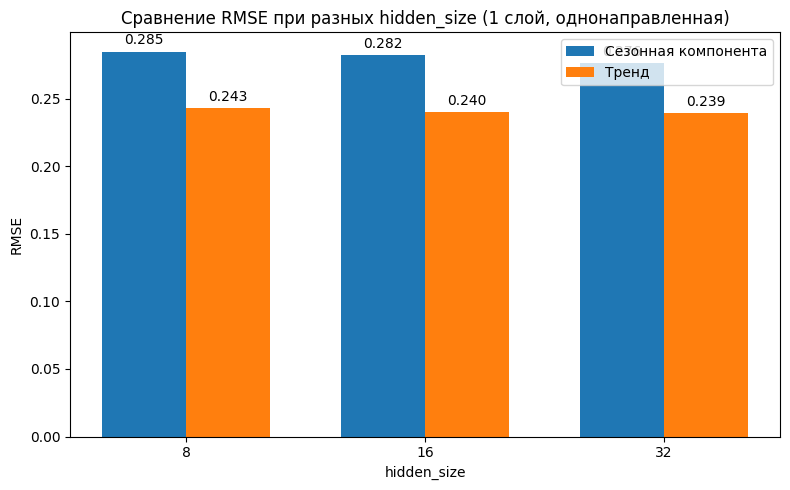

In [43]:
import numpy as np
import matplotlib.pyplot as plt

hidden_sizes = [8, 16, 32]
rmse_seasonal = [results_task4['seasonal'][h] for h in hidden_sizes]
rmse_trend = [results_task4['trend'][h] for h in hidden_sizes]

x = np.arange(len(hidden_sizes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, rmse_seasonal, width, label='Сезонная компонента')
bars2 = ax.bar(x + width/2, rmse_trend, width, label='Тренд')

ax.set_xlabel('hidden_size')
ax.set_ylabel('RMSE')
ax.set_title('Сравнение RMSE при разных hidden_size (1 слой, однонаправленная)')
ax.set_xticks(x)
ax.set_xticklabels(hidden_sizes)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

**Задание 6**

In [44]:
configs = [
    ('1 слой, однонаправл., hidden=8',  1, 8,  False),
    ('1 слой, однонаправл., hidden=16', 1, 16, False),
    ('1 слой, однонаправл., hidden=32', 1, 32, False),
    ('2 слоя, двунаправл., hidden=16',  2, 16, True),
    ('2 слоя, двунаправл., hidden=32',  2, 32, True),
    ('2 слоя, двунаправл., hidden=64',  2, 64, True),
]

print(f'{"Конфигурация":<40} {"Параметров":>12}')
print('-'*55)
for name, layers, hidden, bidir in configs:
    m = LSTM(1, 1, hidden, layers, bidir, 0.2).to(device)
    total = sum(p.numel() for p in m.parameters())
    print(f'{name:<40} {total:>12}')

Конфигурация                               Параметров
-------------------------------------------------------
1 слой, однонаправл., hidden=8                    361
1 слой, однонаправл., hidden=16                  1233
1 слой, однонаправл., hidden=32                  4513
2 слоя, двунаправл., hidden=16                   8865
2 слоя, двунаправл., hidden=32                  34113
2 слоя, двунаправл., hidden=64                 133761


**Ещё эксперементы**

In [45]:
experiments = [
    ('exp4', 80,  512, 0.001,  16),
    ('exp5', 40,  128, 0.001,  16),
    ('exp6', 60,  256, 0.0005, 16),
]

results_task2 = {}

for name, epochs, batch_size, lr, hidden in experiments:
    # Датолодеры с нужным batch_size
    dataset = TensorDataset(tensor_X_train, tensor_y_train)
    dataset_test = TensorDataset(tensor_X_test, tensor_y_test)
    dl_exp = {}
    dl_exp['train'] = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    dl_exp['test'] = DataLoader(dataset_test, batch_size=128, shuffle=False)

    model_exp = LSTM(1, 1, hidden, 2, True, 0.2).to(device)
    optimizer_exp = torch.optim.Adam(model_exp.parameters(), lr=lr)
    scheduler_exp = optim.lr_scheduler.StepLR(optimizer_exp, step_size=20, gamma=0.1)
    criterion_exp = torch.nn.MSELoss()

    best_loss = np.inf
    best_preds = None
    checkpoint_exp = f'ts_{name}.pth'

    for epoch in range(epochs):
        model_exp.train()
        hidden_state = None
        for batch in dl_exp['train']:
            inputs, labels = [xx.to(device) for xx in batch]
            optimizer_exp.zero_grad()
            if hidden_state is not None and inputs.shape[0] != hidden_state[0].shape[1]:
                hidden_state = None
            outputs, hidden_state = model_exp(inputs, hidden_state)
            hidden_state = tuple([e.data for e in hidden_state])
            loss = criterion_exp(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model_exp.parameters(), 1.0)
            optimizer_exp.step()
        scheduler_exp.step()

        model_exp.eval()
        hidden_state = None
        tmp_loss = []
        with torch.no_grad():
            for batch in dl_exp['test']:
                inputs, labels = [xx.to(device) for xx in batch]
                if hidden_state is not None and inputs.shape[0] != hidden_state[0].shape[1]:
                    hidden_state = None
                outputs, hidden_state = model_exp(inputs, hidden_state)
                hidden_state = tuple([e.data for e in hidden_state])
                tmp_loss.append(criterion_exp(outputs, labels).item())
        if np.mean(tmp_loss) < best_loss:
            best_loss = np.mean(tmp_loss)
            torch.save(model_exp.state_dict(), checkpoint_exp)

    model_exp.load_state_dict(torch.load(checkpoint_exp))
    model_exp.eval()
    preds_exp, _ = model_exp(tensor_X_test.to(device))
    preds_exp = preds_exp.detach().cpu().numpy()
    y_true = y[y.shape[0]*9//10:].flatten()
    preds_final = X[X.shape[0]*9//10:, -1] + preds_exp.flatten()
    rmse = (y_true - preds_final).std()
    results_task2[name] = rmse
    print(f'{name} | epochs={epochs}, batch={batch_size}, lr={lr} | RMSE: {rmse:.3f}')

print('Готово')

exp4 | epochs=80, batch=512, lr=0.001 | RMSE: 2.420
exp5 | epochs=40, batch=128, lr=0.001 | RMSE: 2.333
exp6 | epochs=60, batch=256, lr=0.0005 | RMSE: 2.439
Готово
